### Failed Program Analysis


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from datetime import datetime
from statsmodels.graphics.tsaplots import plot_acf

failed_program_path = "/data0/xiaoyez/Solana_Ecosystem/data/top_failed_program/top_failed_program.csv"
failed_program_df = pd.read_csv(failed_program_path)
failed_program_df.head()

,program_id,failed_count
0,675kPX9MHTjS2zt1qfr1NYHuzeLXfQM9H24wFSUt1Mp8,327650466.0
1,JUP6LkbZbjS1jKKwapdHNy74zcZ3tLUZoi5QNyVTaV4,252017540.0
2,cjg3oHmg9uuPsP8D6g29NWvhySJkdYdAo9D25PRbKXJ,226952883.0
3,6Q4Xu2sXxMLMhS2pSBJwhDrL5AMWGbrBT3yaN48kYX7G,87172461.0
4,JUP4Fb2cqiRUcaTHdrPC8h2gNsA2ETXiPDD33WcGuJB,84279822.0


In [7]:
def get_failed_program_meta_stats(failed_program_df):
    print(f"Total failed programs: {len(failed_program_df)}")
    print(f"Max failed count: {failed_program_df['failed_count'].max()}")
    print(f"Min failed count: {failed_program_df['failed_count'].min()}")
    print(f"Mean failed count: {failed_program_df['failed_count'].mean()}")
    print(f"Median failed count: {failed_program_df['failed_count'].median()}")
    print(f"Std failed count: {failed_program_df['failed_count'].std()}")

get_failed_program_meta_stats(failed_program_df)

Total failed programs: 2324
Max failed count: 327650466.0
Min failed count: 1.0
Mean failed count: 649411.0425989673
Median failed count: 30.0
Std failed count: 10328994.4312245


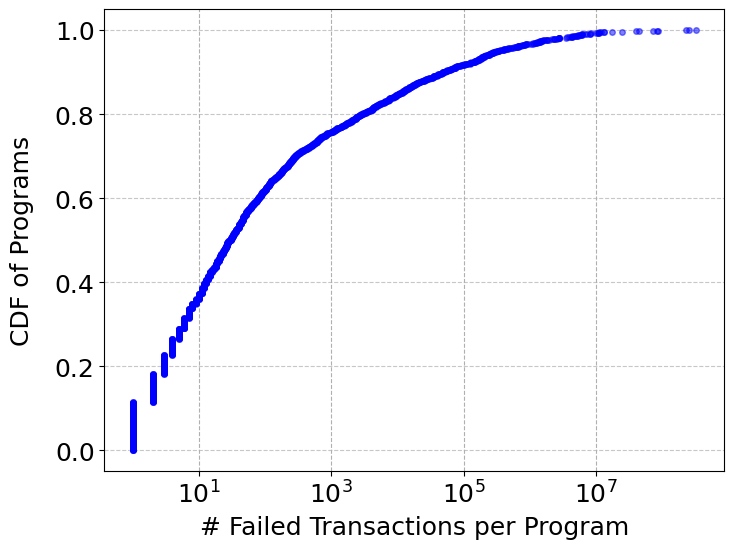

In [20]:
def plot_failed_cdf(failed_program_df):
    programs_cdfx = np.sort(failed_program_df['failed_count'])
    programs_cdfy = np.linspace(1 / len(failed_program_df['failed_count']), 1.0, len(failed_program_df['failed_count']))  


    plt.figure(figsize=(8, 6))
    plt.semilogx(programs_cdfx, programs_cdfy, 'o', color='blue', 
                 markersize=4,      # Size of dots
                 alpha=0.5,         # Transparency
                 rasterized=True)   # Better performance for many points

    # 添加标题和标签
    # plt.title(f'CDF of Failed #Txs')
    plt.ylabel('CDF of Programs', labelpad=15)
    plt.xlabel('# Failed Transactions per Program', labelpad=5)
    plt.grid(True, which='both', axis='y', linestyle='--', alpha=0.7) 
    # label size
    ax = plt.gca()
    ax.tick_params(labelsize=18)
    ax.yaxis.label.set_size(18)
    ax.xaxis.label.set_size(18)
    ax.title.set_size(20)
    plt.grid(True, linestyle='--', which="major")
    plt.savefig(f'/data0/xiaoyez/Solana_Ecosystem/src/analyze/RQ1/output_fig/9_failed_program_cdf.png', dpi=300) 
    plt.show()


plot_failed_cdf(failed_program_df)

In [7]:
# Analyze top 15 failed programs
def cal_program_success_count(program_id):
    split_num = 4
    success_count = 0
    if program_id == '675kPX9MHTjS2zt1qfr1NYHuzeLXfQM9H24wFSUt1Mp8':
        file_success_df = pd.read_csv("/data0/xiaoyez/Solana_Ecosystem/data/program_success/675kPX9MHTjS2zt1qfr1NYHuzeLXfQM9H24wFSUt1Mp8.csv")
        return file_success_df['unique_signature_count'].sum()
    for i in range(1, split_num + 1):
        file_success_path = f"/data0/xiaoyez/Solana_Ecosystem/data/program_success/{i}/{program_id[:10]}.csv"
        if os.path.exists(file_success_path):
            file_success_df = pd.read_csv(file_success_path)
            success_count += file_success_df['unique_signature_count'].sum()
    return success_count

def get_program_signer_count(program_id):
    file_signer_path = f"/data0/xiaoyez/Solana_Ecosystem/data/program_signer/{program_id}.csv"
    if os.path.exists(file_signer_path):
        file_signer_df = pd.read_csv(file_signer_path)
        return file_signer_df['unique_signer_count'].sum()
    else:
        print(f"File {file_signer_path} does not exist")
    return 0

def get_total_tx_count():
    time_trend_dir = "/data0/xiaoyez/Solana_Ecosystem/data/time_trend"
    total_tx_count = 0
    for file in os.listdir(time_trend_dir):
        if file.endswith(".csv"):
            file_path = os.path.join(time_trend_dir, file)
            file_df = pd.read_csv(file_path)
            for i, row in file_df.iterrows():
                total_tx_count += row['total_txs']*row['failed_ratio']
    return total_tx_count

total_failed_tx_count = get_total_tx_count()
print(f"Total failed tx count: {total_failed_tx_count}")
top_15_failed_program_df = failed_program_df[:15].copy()
top_15_failed_program_df['failed_perct'] = top_15_failed_program_df['failed_count'] / total_failed_tx_count
top_15_failed_program_df['success_count'] = top_15_failed_program_df['program_id'].apply(cal_program_success_count)
top_15_failed_program_df['failure_rate'] = top_15_failed_program_df['failed_count'] / (top_15_failed_program_df['success_count'] + top_15_failed_program_df['failed_count'])
top_15_failed_program_df['signer_count'] = top_15_failed_program_df['program_id'].apply(get_program_signer_count)
top_15_failed_program_df

Total failed tx count: 1510834168.0


,program_id,failed_count,failed_perct,success_count,failure_rate,signer_count
0,675kPX9MHTjS2zt1qfr1NYHuzeLXfQM9H24wFSUt1Mp8,327650466.0,0.216867,113847089.0,0.742134,1565324.0
1,JUP6LkbZbjS1jKKwapdHNy74zcZ3tLUZoi5QNyVTaV4,252017540.0,0.166807,64045907.0,0.797364,1115631.0
2,cjg3oHmg9uuPsP8D6g29NWvhySJkdYdAo9D25PRbKXJ,226952883.0,0.150217,14028523.0,0.941786,23.0
3,6Q4Xu2sXxMLMhS2pSBJwhDrL5AMWGbrBT3yaN48kYX7G,87172461.0,0.057698,777238.0,0.991163,105.0
4,JUP4Fb2cqiRUcaTHdrPC8h2gNsA2ETXiPDD33WcGuJB,84279822.0,0.055784,3383540.0,0.961403,5816.0
5,GDDMwNyyx8uB6zrqwBFHjLLG3TBYk2F8Az4yrQC5RzMp,71616610.0,0.047402,120038169.0,0.373675,105.0
6,ATokenGPvbdGVxr1b2hvZbsiqW5xWH25efTNsLJA8knL,44956578.0,0.029756,91707788.0,0.328956,544818.0
7,9uW2TqLyfYyrcNVrgCy4jPpqDKQoBZhXWypzzFxbixQE,40817555.0,0.027017,974873.0,0.976673,924.0
8,YmirFH6wUrtUMUmfRPZE7TcnszDw689YNWYrMgyB55N,24635690.0,0.016306,1240428.0,0.952063,4.0
9,3J3HFc8jXxdvZQ73PeUPJmPdM2EKpKonzBaYACCXzqkv,17509217.0,0.011589,1574170.0,0.917511,7.0


### Temporal Trends

Total txs: 2898175006.0
Total failed txs: 1510834168.0
Total success txs: 1387340838.0
Correlation between failed non vote count and failed non vote ratio: 0.7049033454848862
Data range from 2023-08-04 00:00:00.000 UTC to 2024-07-31 23:00:00.000 UTC


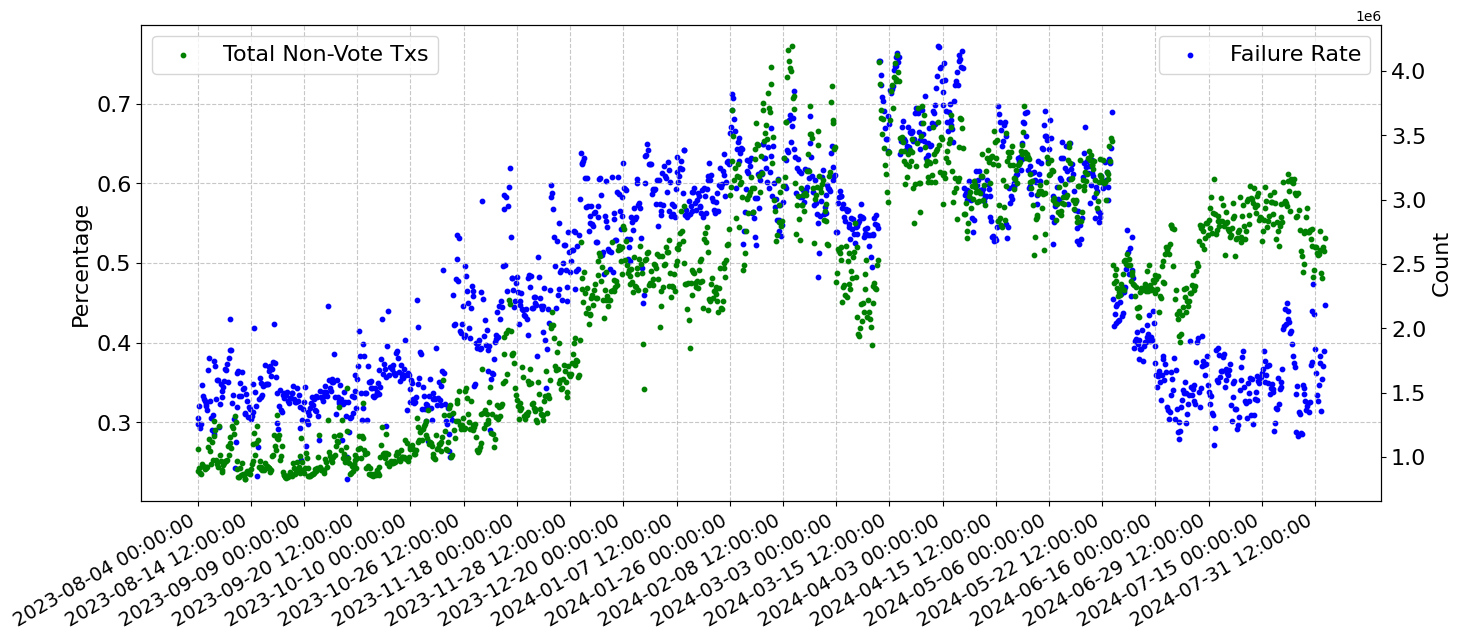

,hour,total_txs,failed_ratio
0,2023-08-04 00:00:00.000 UTC,1060048.0,0.305900
1,2023-08-04 01:00:00.000 UTC,888734.0,0.297449
2,2023-08-04 02:00:00.000 UTC,913720.0,0.320222
3,2023-08-04 03:00:00.000 UTC,874687.0,0.292327
4,2023-08-04 04:00:00.000 UTC,871574.0,0.297471


In [2]:
def get_hourly_tx_ratio_df():
    time_trend_dir = "/data0/xiaoyez/Solana_Ecosystem/data/time_trend"
    hourly_tx_ratio_df = pd.DataFrame()
    files = sorted(os.listdir(time_trend_dir))
    for file in files:
        if file.endswith(".csv"):
            file_path = os.path.join(time_trend_dir, file)
            file_df = pd.read_csv(file_path)
            hourly_tx_ratio_df = pd.concat([hourly_tx_ratio_df, file_df[['hour', 'total_txs', 'failed_ratio']]], ignore_index=True)
    print(f"Total txs: {sum(hourly_tx_ratio_df['total_txs'])}")
    print(f"Total failed txs: {sum(hourly_tx_ratio_df['failed_ratio'] * hourly_tx_ratio_df['total_txs'])}")
    print(f"Total success txs: {sum(hourly_tx_ratio_df['total_txs'] - hourly_tx_ratio_df['failed_ratio'] * hourly_tx_ratio_df['total_txs'])}")
    return hourly_tx_ratio_df

def plot_tx_cnt_per_hour(hourly_tx_ratio_df):
    # block_ids = pd.to_datetime(hourly_tx_ratio_df['hour'], format='%Y-%m-%d %H:%M:%S.%f UTC')
    block_ids = hourly_tx_ratio_df['hour'].tolist()
    block_ids = [block_id.split('.')[0] for block_id in block_ids]
    total_count = hourly_tx_ratio_df['total_txs'].tolist()
    failed_non_vote_ratio = hourly_tx_ratio_df['failed_ratio'].tolist()

    assert len(block_ids) == len(total_count) == len(failed_non_vote_ratio)
    print("Data range from", min(hourly_tx_ratio_df['hour']), "to", max(hourly_tx_ratio_df['hour']))

    fig2, ax2 = plt.subplots(figsize=(16, 7))
    colors = ['crimson', 'blue']
    # j = 0
    # for i in [0] + list(range(8, len(block_ids)-1, 12)):
    #     if i == 0:
    #         ax2.axvspan(block_ids[i], block_ids[i+8], color=colors[j%2], alpha=0.2)
    #     else:
    #         ax2.axvspan(block_ids[i], block_ids[i+12 if i+12 < len(block_ids)-1 else len(block_ids)-1], color=colors[j%2], alpha=0.2)
    #     j = j + 1
    ax3 = ax2.twinx()
    ax2.scatter(block_ids, failed_non_vote_ratio, label='Failure Rate', color='blue', s=10)
    # ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d-%H'))
    # specific_hours = [ 20]  # 只显示8:00和20:00
    # ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:00'))
    # # ax2.xaxis.set_major_locator(mdates.HourLocator(byhour=specific_hours)) 
    # # ax2.set_xlim(min(block_ids), max(block_ids))  # 设置x轴范围
    # ax2.xaxis.set_major_locator(mdates.DayLocator(interval=4))
    # ax2.set_xlim(min(block_ids), max(block_ids)) 
    tick_indices = range(0, len(block_ids), 60)
    tick_positions = [block_ids[i] for i in tick_indices]
    ax2.set_xticks(tick_positions)
    

    ax2.legend(loc='upper right', fontsize=16)
    ax2.set_ylabel('Percentage', fontsize=16)
    
    ax3.scatter(block_ids, total_count, label='Total Non-Vote Txs', color='green', s=10)
    ax3.legend(loc='upper left', fontsize=16)
    ax3.set_ylabel('Count', fontsize=16)
    ax2.tick_params(axis='y', labelsize=16)
    ax3.tick_params(axis='y', labelsize=16)

    ax2.tick_params(axis='x', labelsize=14)

    ax2.grid(True, which='both', axis='y', linestyle='--', alpha=0.7) 
    ax2.grid(True, which='both', axis='x', linestyle='--', alpha=0.7) 

    fig2.autofmt_xdate()
    # 显示图表
    fig2.savefig('/data0/xiaoyez/Solana_Ecosystem/src/dune_analyze/fig/1_failed_ratio_one_year.png', dpi=300) 
    plt.show()

def calculate_correlation_count_ratio(hourly_tx_ratio_df):
    failed_non_vote_counts = hourly_tx_ratio_df['total_txs'].tolist()
    failed_non_vote_ratio = hourly_tx_ratio_df['failed_ratio'].tolist()
    # calculate correlation
    corr = np.corrcoef(failed_non_vote_counts, failed_non_vote_ratio)
    print(f"Correlation between failed non vote count and failed non vote ratio: {corr[0][1]}")

def my_plot_acf(data, is_count=True, lags=24*5):
    fig, ax = plt.subplots(figsize=(12, 6))
    plot_acf(data, lags=lags, ax=ax)
    # Customize the plot (optional)
    # plt.title("Autocorrelation Function (ACF)")
    plt.xlabel("Lag", fontsize=18)
    plt.ylabel("Autocorrelation", fontsize=18)
    plt.tick_params(axis='both', which='major', labelsize=16)
    out_name = "count" if is_count else "ratio"
    plt.grid(True, linestyle='--', alpha=0.7)
    for i in range(1, 6):
        plt.axvline(x=24*i, color='red', linestyle='--', alpha=0.5)

    plt.savefig(f"/data0/xiaoyez/Solana_Ecosystem/src/analyze/RQ1/output_fig/2_acf_{out_name}.png", dpi=300)
    plt.show()

hourly_tx_ratio_df = get_hourly_tx_ratio_df()

calculate_correlation_count_ratio(hourly_tx_ratio_df)
plot_tx_cnt_per_hour(hourly_tx_ratio_df)
# my_plot_acf(hourly_tx_ratio_df['total_txs'].tolist(), is_count=True)
# my_plot_acf(hourly_tx_ratio_df['failed_ratio'].tolist(), is_count=False)

hourly_tx_ratio_df.head()


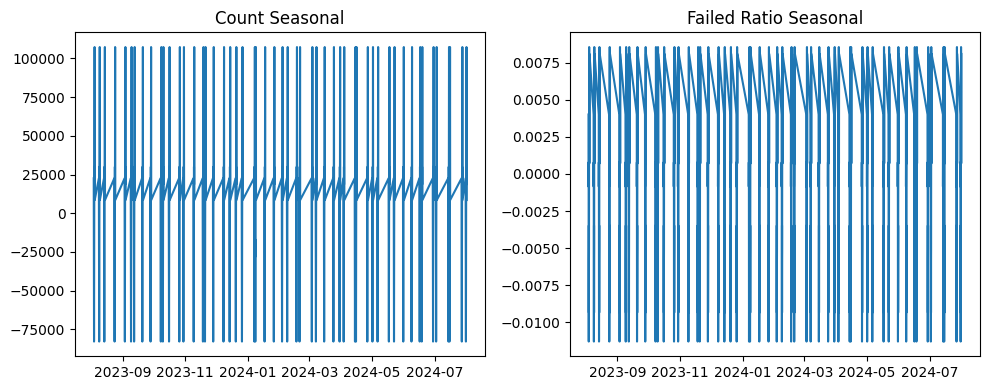

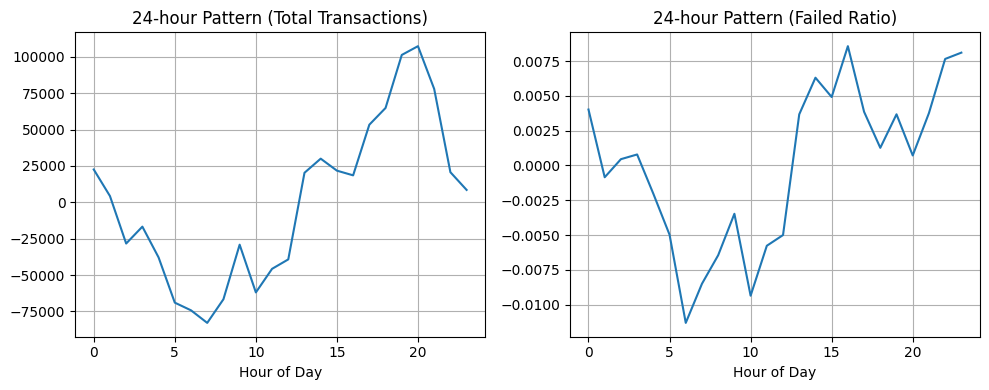

In [17]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
from scipy import stats

# 1. 确保时间列是datetime格式
hourly_tx_ratio_df['hour'] = pd.to_datetime(hourly_tx_ratio_df['hour'])

# 2. 设置时间索引
# 分别分析 total_txs 和 failed_ratio
df_total = hourly_tx_ratio_df.set_index('hour')['total_txs']
df_ratio = hourly_tx_ratio_df.set_index('hour')['failed_ratio']

# 3. 进行时间序列分解
# 分析 total_txs
decomp_total = seasonal_decompose(df_total, period=24)  # 24小时为一个周期

# 绘制total_txs的分解结果
plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.plot(decomp_total.seasonal)
plt.title('Count Seasonal')
plt.tight_layout()

# 分析 failed_ratio
decomp_ratio = seasonal_decompose(df_ratio, period=24)
# 绘制failed_ratio的分解结果
plt.subplot(122)
plt.plot(decomp_ratio.seasonal)
plt.title('Failed Ratio Seasonal')
plt.tight_layout()

# 4. 查看seasonal部分的具体模式
seasonal_pattern_total = pd.DataFrame(decomp_total.seasonal[:24])
seasonal_pattern_ratio = pd.DataFrame(decomp_ratio.seasonal[:24])

# 绘制24小时周期模式
plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.plot(range(24), seasonal_pattern_total)
plt.title('24-hour Pattern (Total Transactions)')
plt.xlabel('Hour of Day')
plt.grid(True)

plt.subplot(122)
plt.plot(range(24), seasonal_pattern_ratio)
plt.title('24-hour Pattern (Failed Ratio)')
plt.xlabel('Hour of Day')
plt.grid(True)
plt.tight_layout()

### Rank, Fee, CU, Fee Per CU

In [5]:
# rank
rank_file_path = "/data0/xiaoyez/Solana_Ecosystem/data/index_rank/index_rank.csv"
rank_df = pd.read_csv(rank_file_path)
pd.set_option('display.float_format', lambda x: '%.0f' % x)
print(rank_df)

    status      count  min_index  max_index  mean_index  median_index
0   failed 1510834168          0       8134         754           592
1  success 1387340838          0       8264         764           529


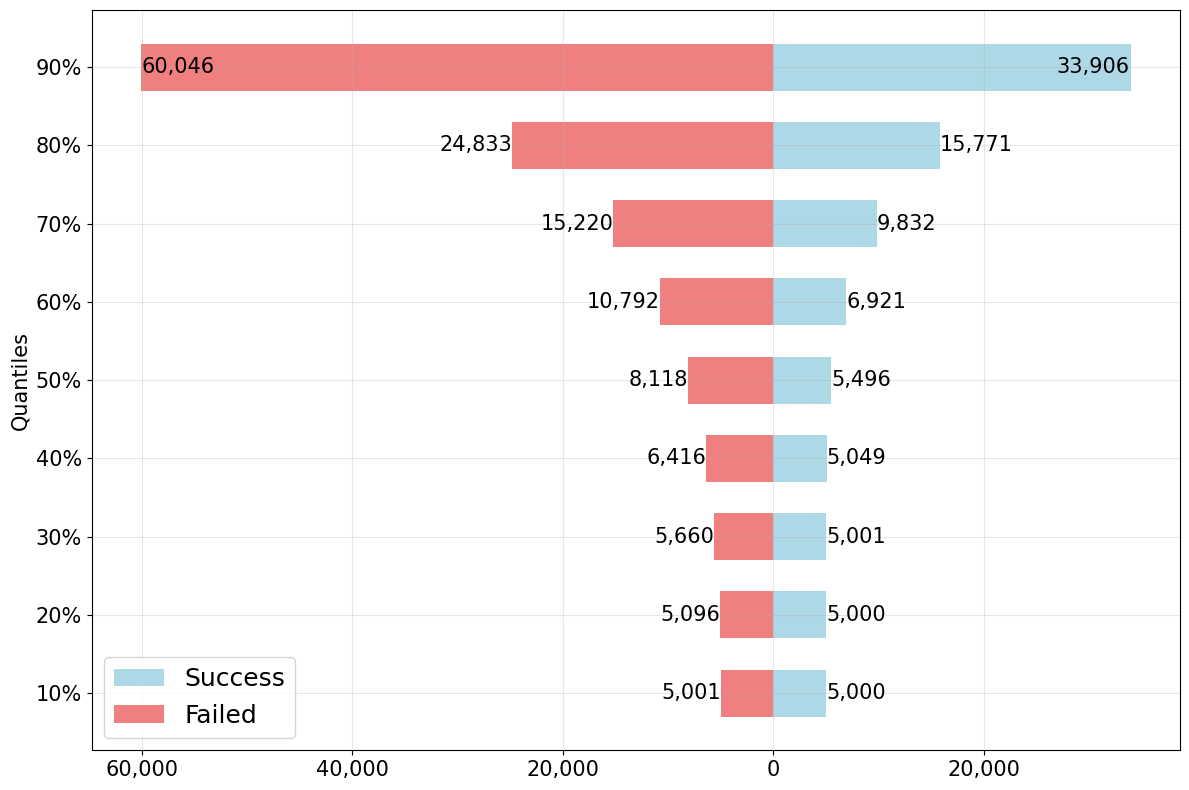

In [3]:
def plot_percentile(df: pd.DataFrame, item:str):
    quantiles = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
    failed_fee = df[df['status']=='failed'][f'fee_percentiles'].iloc[0][1:-1].split(' ')
    success_fee = df[df['status']=='success'][f'fee_percentiles'].iloc[0][1:-1].split(' ')
    assert len(failed_fee) == len(success_fee) == len(quantiles)
    failed_fee = [int(x.strip(',')) for x in failed_fee]
    success_fee = [int(x.strip(',')) for x in success_fee]

    # 创建图形和轴
    fig, ax = plt.subplots(figsize=(12, 8))
    y_positions = np.arange(len(quantiles))

    ax.barh(y_positions, success_fee, height=0.6, color='lightblue', label='Success')
    ax.barh(y_positions, [-x for x in failed_fee], height=0.6, color='lightcoral', label='Failed')

    def set_bar_text(ax, fee, y_positions, left=False): 
        for i, (value, y_pos) in enumerate(zip(fee, y_positions)):
            if i == len(fee) - 1:
                text_pos = -value+7000 if left else value-7000
                ax.text(text_pos, y_pos, f'{value:,}', 
                        va='center', ha='right' if left else 'left', fontsize=15)
            else:
                text_pos = -value if left else value
                ax.text(text_pos, y_pos, f'{value:,}', 
                        va='center', ha='right' if left else 'left', fontsize=15)
    set_bar_text(ax, failed_fee, y_positions, left=True)
    set_bar_text(ax, success_fee, y_positions, left=False)
  

    ax.set_yticks(y_positions)
    # ax.set_yticklabels([f'{x:.2f}' for x in quantiles], fontsize=15)
    ax.set_yticklabels([f'{x*100:.0f}%' for x in quantiles], fontsize=15)
    # ax.set_xlabel(item, fontsize=15)
    ax.set_ylabel('Quantiles', fontsize=15)

    # plt.title('Distribution of Success and Failed Cases', fontsize=12)
    plt.legend(fontsize=18)
    ax.grid(True, alpha=0.3)

    def format_func(value, tick_number):
        if value < 0:
            return f'{int(abs(value)):,}'
        return f'{int(value):,}'

    ax.xaxis.set_major_formatter(plt.FuncFormatter(format_func))
    ax.tick_params(axis='x', labelsize=15)
    plt.tight_layout()
    plt.savefig(f'/data0/xiaoyez/Solana_Ecosystem/src/dune_analyze/fig/{item}_percentile_one_year.png', dpi=300)
    plt.show()


# Fee
fee_file_path = "/data0/xiaoyez/Solana_Ecosystem/data/fee/fee.csv"
fee_df = pd.read_csv(fee_file_path)
pd.set_option('display.float_format', lambda x: '%.0f' % x)
fee_df.head()
plot_percentile(fee_df, "Fee")





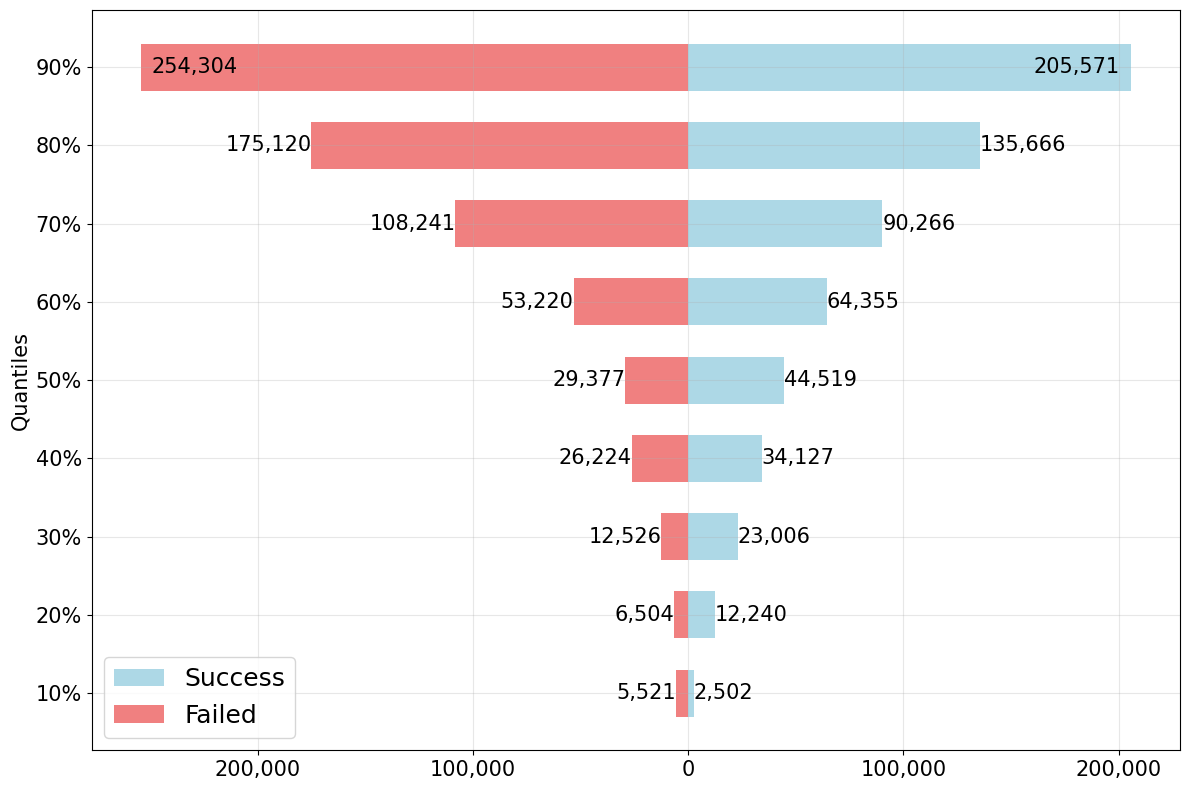

In [9]:
def plot_percentile(df: pd.DataFrame, item:str):
    quantiles = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
    failed_fee = df[df['status']=='failed'][f'percentiles'].iloc[0][1:-1].split(' ')
    success_fee = df[df['status']=='success'][f'percentiles'].iloc[0][1:-1].split(' ')
    assert len(failed_fee) == len(success_fee) == len(quantiles)
    failed_fee = [int(float(x.strip(','))) for x in failed_fee]
    success_fee = [int(float(x.strip(','))) for x in success_fee]

    # 创建图形和轴
    fig, ax = plt.subplots(figsize=(12, 8))
    y_positions = np.arange(len(quantiles))

    ax.barh(y_positions, success_fee, height=0.6, color='lightblue', label='Success')
    ax.barh(y_positions, [-x for x in failed_fee], height=0.6, color='lightcoral', label='Failed')

    def set_bar_text(ax, fee, y_positions, left=False): 
        for i, (value, y_pos) in enumerate(zip(fee, y_positions)):
            if i == len(fee) - 1:
                text_pos = -value+45000 if left else value-45000
                ax.text(text_pos, y_pos, f'{value:,}', 
                        va='center', ha='right' if left else 'left', fontsize=15)
            else:
                text_pos = -value if left else value
                ax.text(text_pos, y_pos, f'{value:,}', 
                        va='center', ha='right' if left else 'left', fontsize=15)
    set_bar_text(ax, failed_fee, y_positions, left=True)
    set_bar_text(ax, success_fee, y_positions, left=False)
  

    ax.set_yticks(y_positions)
    # ax.set_yticklabels([f'{x:.2f}' for x in quantiles], fontsize=15)
    ax.set_yticklabels([f'{x*100:.0f}%' for x in quantiles], fontsize=15)
    # ax.set_xlabel(item, fontsize=15)
    ax.set_ylabel('Quantiles', fontsize=15)

    # plt.title('Distribution of Success and Failed Cases', fontsize=12)
    plt.legend(fontsize=18)
    ax.grid(True, alpha=0.3)

    def format_func(value, tick_number):
        if value < 0:
            return f'{int(abs(value)):,}'
        return f'{int(value):,}'

    ax.xaxis.set_major_formatter(plt.FuncFormatter(format_func))
    ax.tick_params(axis='x', labelsize=15)
    plt.tight_layout()
    plt.savefig(f'/data0/xiaoyez/Solana_Ecosystem/src/dune_analyze/fig/{item}_percentile_one_year.png', dpi=300)
    # plt.show()


# CU
cu_file_path = "/data0/xiaoyez/Solana_Ecosystem/data/cu/cu.csv"
cu_df = pd.read_csv(cu_file_path)
pd.set_option('display.float_format', lambda x: '%.0f' % x)
cu_df.head()
plot_percentile(cu_df, "cu")

,status,min_cu,max_cu,mean_cu,median_cu,percentiles
0,failed,0,20666700,9,0,"[0.03, 0.05, 0.14, 0.24, 0.44, 0.77, 0.77, 1.3..."
1,success,0,1777789,11,0,"[0.03, 0.05, 0.08, 0.13, 0.18, 0.29, 0.48, 1.1..."


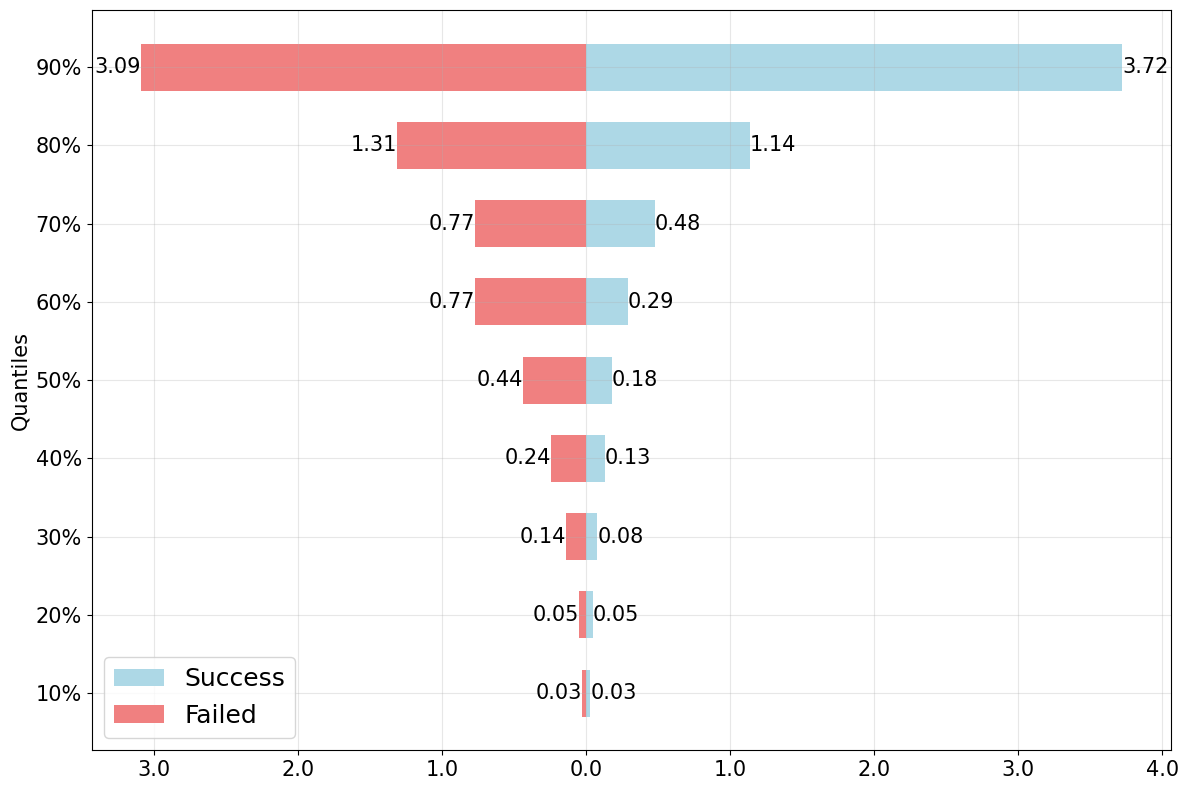

In [10]:
def plot_percentile(df: pd.DataFrame, item:str):
    quantiles = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
    failed_fee = df[df['status']=='failed'][f'percentiles'].iloc[0][1:-1].split(' ')
    success_fee = df[df['status']=='success'][f'percentiles'].iloc[0][1:-1].split(' ')
    assert len(failed_fee) == len(success_fee) == len(quantiles)
    failed_fee = [float(x.strip(',')) for x in failed_fee]
    success_fee = [float(x.strip(',')) for x in success_fee]

    # 创建图形和轴
    fig, ax = plt.subplots(figsize=(12, 8))
    y_positions = np.arange(len(quantiles))

    ax.barh(y_positions, success_fee, height=0.6, color='lightblue', label='Success')
    ax.barh(y_positions, [-x for x in failed_fee], height=0.6, color='lightcoral', label='Failed')

    def set_bar_text(ax, fee, y_positions, left=False): 
        for i, (value, y_pos) in enumerate(zip(fee, y_positions)):
            if i == len(fee) - 1:
                text_pos = -value if left else value
                ax.text(text_pos, y_pos, f'{value:,}', 
                        va='center', ha='right' if left else 'left', fontsize=15)
            else:
                text_pos = -value if left else value
                ax.text(text_pos, y_pos, f'{value:,}', 
                        va='center', ha='right' if left else 'left', fontsize=15)
    set_bar_text(ax, failed_fee, y_positions, left=True)
    set_bar_text(ax, success_fee, y_positions, left=False)
  

    ax.set_yticks(y_positions)
    ax.set_yticklabels([f'{x*100:.0f}%' for x in quantiles], fontsize=15)

    # ax.set_yticklabels([f'{x:.2f}' for x in quantiles], fontsize=15)
    # ax.set_xlabel(item, fontsize=15)
    ax.set_ylabel('Quantiles', fontsize=15)

    # plt.title('Distribution of Success and Failed Cases', fontsize=12)
    plt.legend(fontsize=18)
    ax.grid(True, alpha=0.3)

    def format_func(value, tick_number):
        if value < 0:
            return f'{abs(value):,}'
        return f'{value:,}'

    ax.xaxis.set_major_formatter(plt.FuncFormatter(format_func))
    ax.tick_params(axis='x', labelsize=15)
    plt.tight_layout()
    plt.savefig(f'/data0/xiaoyez/Solana_Ecosystem/src/dune_analyze/fig/{item}_percentile_one_year.png', dpi=300)

# Fee Per CU
fee_per_cu_file_path = "/data0/xiaoyez/Solana_Ecosystem/data/cu/fee_per_cu.csv"
fee_per_cu_df = pd.read_csv(fee_per_cu_file_path)
pd.set_option('display.float_format', lambda x: '%.0f' % x)
plot_percentile(fee_per_cu_df, "Fee Per CU")
fee_per_cu_df.head()
